In [76]:
                            #### IN VIVO EXPERIMENTS SAMPLE SIZE CALCULATION ####
                           

In [77]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
pd.DataFrame.iteritems = pd.DataFrame.items
from random import gauss as rgauss
import numpy as np
import re

np.float = float
from scipy.stats.mstats import gmean

from tqdm.notebook import tqdm

import pingouin as pg

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [78]:
def mgauss(mu=1, sigma=.1, threshold=2):
    """This limits the generated values within ± <threshold> standard deviations
    """
    
    val = mu + sigma * threshold * 2

    while abs(val - mu) > sigma * threshold: 
        val = rgauss(mu, sigma)

    return val

In [79]:
###  GBM size in orthotopic mice models ###

# Mean and standard deviation values of GBM size in untreated and TMZ-treated orthotopic mouse models 
# were retrieved from available literature (e.g. doi:10.1038/s41467-023-40579-1; 10.1038/s41419-026-08879-8) 
# and computed as fold change vs untreated condition.


In [80]:
# params

size_std = 0.11       # standard deviation of GBM size
size_high = 1         # mean GBM size in untreated orthotopic mice (e.g. SEMA6Ahigh)
size_high_tmz = 0.77  # mean GBM size in TMZ-treated orthotopic mice (e.g. SEMA6Ahigh_tmz)

size_low = 0.8        # expected mean GBM size of untreated orthotopic mice with low SEMA6A (-20% vs SEMA6Ahigh)
size_low_tmz = 0.5    # expected mean GBM size of treated orthotopic mice with low SEMA6A (-50% vs SEMA6Ahigh)

<Axes: >

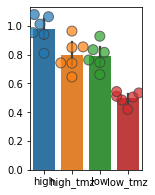

In [81]:
#plot an example

n = 6 # numerosity per experimental group

high     = [mgauss(mu=size_high,     sigma=size_std * size_high,     threshold=3) for _ in range(n)]
high_tmz = [mgauss(mu=size_high_tmz, sigma=size_std * size_high_tmz, threshold=3) for _ in range(n)]
low      = [mgauss(mu=size_low,      sigma=size_std * size_low,      threshold=3) for _ in range(n)]
low_tmz  = [mgauss(mu=size_low_tmz,  sigma=size_std * size_low_tmz,  threshold=3) for _ in range(n)]

repack = {"high": high, "high_tmz": high_tmz, "low": low, "low_tmz": low_tmz}
repack = pd.DataFrame(repack, index=range(n))

plt.figure(figsize=(2,3))
sns.barplot(data=repack)
sns.swarmplot(data=repack, s=10, linewidth=1, alpha=.7)

In [82]:
n_values = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
t_power = []
a_power1 = []
a_power2 = []
a_power3 = []

#compute p-values for ttest and Tukey's post-hoc test over 1000 simulations
for n in n_values:
    t_pvals = []
    a_pvals1 = []
    a_pvals2 = []
    a_pvals3 = []
 

    n_sims = 1000
    for i in tqdm(range(n_sims)):
        high     = [mgauss(mu=size_high,     sigma=size_std * size_high,     threshold=3) for _ in range(n)]
        high_tmz = [mgauss(mu=size_high_tmz, sigma=size_std * size_high_tmz, threshold=3) for _ in range(n)]
        low      = [mgauss(mu=size_low,      sigma=size_std * size_low,      threshold=3) for _ in range(n)]
        low_tmz  = [mgauss(mu=size_low_tmz,  sigma=size_std * size_low_tmz,  threshold=3) for _ in range(n)]
    
        t_res = pg.ttest(high, high_tmz)
        t_pval = t_res["p-val"].iloc[0]
        t_pvals.append(t_pval)

        repacked_vals = high + high_tmz + low + low_tmz
        repacked_hues = ["high" for _ in range(n)] + ["high_tmz" for _ in range(n)] + ["low" for _ in range(n)] + ["low_tmz" for _ in range(n)]
        repack = {"vals": repacked_vals, "tags": repacked_hues}
        repack = pd.DataFrame(repack, index=range(n * 4))
        #a_res = pg.anova(data=repack, dv='vals', between='tags', detailed=False)
        posthoc = pg.pairwise_tests(data=repack, dv='vals', between='tags', parametric=True, padjust='fdr_bh', effsize='hedges')
        a_pval1 = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "low")]["p-corr"].iloc[0]
        a_pval2 = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "high_tmz")]["p-corr"].iloc[0]
        a_pval3 = posthoc[(posthoc["A"] == "high") &  (posthoc["B"] == "low_tmz")]["p-corr"].iloc[0]
        a_pvals1.append(a_pval1)
        a_pvals2.append(a_pval2)
        a_pvals3.append(a_pval3)
        
        
    t = np.array(t_pvals)
    a1 = np.array(a_pvals1)
    a2 = np.array(a_pvals2)
    a3 = np.array(a_pvals3)
    t_pow = sum(t < .05)
    a_pow1 = sum(a1 < .05)
    a_pow2 = sum(a2 < .05)
    a_pow3 = sum(a3 < .05)
    
    t_power.append(t_pow)
    a_power1.append(a_pow1)
    a_power2.append(a_pow2)
    a_power3.append(a_pow3)
    print(f"For n = {n} the power of ttest is {sum(t < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is {sum(a1 < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is {sum(a2 < .05)/10}%")
    print(f"For n = {n} the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow_tmz is {sum(a3 < .05)/10}%")
    
        

  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 4 the power of ttest is 82.0%
For n = 4 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 63.0%
For n = 4 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 75.0%
For n = 4 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow_tmz is 99.9%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 5 the power of ttest is 91.0%
For n = 5 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 76.5%
For n = 5 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 87.6%
For n = 5 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow_tmz is 100.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

...

For n = 13 the power of ttest is 100.0%
For n = 13 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 100.0%
For n = 13 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 100.0%
For n = 13 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow_tmz is 100.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 14 the power of ttest is 100.0%
For n = 14 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 99.9%
For n = 14 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 100.0%
For n = 14 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow_tmz is 100.0%


  0%|          | 0/1000 [00:00<?, ?it/s]

For n = 15 the power of ttest is 100.0%
For n = 15 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow is 99.9%
For n = 15 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Ahigh_tmz is 100.0%
For n = 15 the power of Tukey's post-hoc test between SEMA6Ahigh and SEMA6Alow_tmz is 100.0%


In [83]:
posthoc

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,tags,high,high_tmz,False,True,6.321732,28.0,two-sided,7.734404e-07,1.160161e-06,fdr_bh,1.494e+04,2.245982
1,tags,high,low,False,True,5.359880,28.0,two-sided,1.037692e-05,1.245231e-05,fdr_bh,1486.373,1.904256
2,tags,high,low_tmz,False,True,19.745482,28.0,two-sided,5.674680e-18,3.404808e-17,fdr_bh,4.308e+14,7.015165
3,tags,high_tmz,low,False,True,-0.799485,28.0,two-sided,4.307399e-01,4.307399e-01,fdr_bh,0.439,-0.284041
4,tags,high_tmz,low_tmz,False,True,8.958108,28.0,two-sided,1.030165e-09,2.060330e-09,fdr_bh,6.458e+06,3.182632
5,tags,low,low_tmz,False,True,9.837339,28.0,two-sided,1.380640e-10,4.141920e-10,fdr_bh,4.212e+07,3.495005


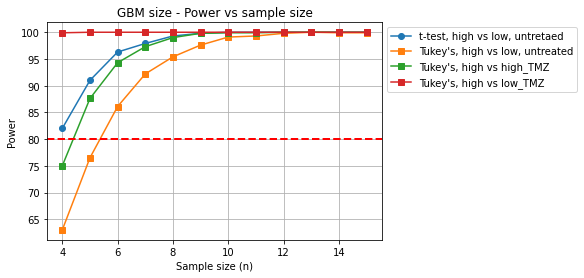

In [84]:
plt.figure()

plt.plot(n_values, np.array(t_power)/10, marker='o', label='t-test, high vs low, untretaed')
plt.plot(n_values, np.array(a_power1)/10, marker='s', label="Tukey's, high vs low, untreated")
plt.plot(n_values, np.array(a_power2)/10, marker='s', label="Tukey's, high vs high_TMZ")
plt.plot(n_values, np.array(a_power3)/10, marker='s', label="Tukey's, high vs low_TMZ")

plt.xlabel('Sample size (n)')
plt.ylabel('Power')
plt.title('GBM size - Power vs sample size')


threshold = 80
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)

plt.show()